In [1]:
%matplotlib inline
import cmlreaders as cml
from cmlreaders import CMLReader, get_data_index
import matplotlib.pyplot as plt 
import matplotlib as mp
from matplotlib.ticker import StrMethodFormatter
from matplotlib.lines import Line2D

import scipy 
from scipy import stats 

import pandas as pd 
import numpy as np
import os 
import sys

import pybeh_pd as pb
import pybeh_pd_min as pb_min
import seaborn as sns
import importlib

from brokenaxes import brokenaxes
import seaborn as sns

import pickle

In [2]:
def loftus_masson(df, sub_cols, cond_col, value_col, within_cols=[]):
    if not isinstance(sub_cols, list):
        sub_cols = [sub_cols]
    if not isinstance(within_cols, list):
        within_cols = [within_cols]
    df = df.copy()
    if len(within_cols) > 0:
        df['M'] = df.groupby(within_cols)[value_col].transform('mean')
    else:
        df['M'] = df[value_col].mean()
    df['M_S'] = df.groupby(sub_cols + within_cols)[value_col].transform('mean')
    df['adj_' + value_col] = (df[value_col] + df['M'] - df['M_S'])
    return df

In [3]:
exp2_data = pd.read_csv('dataframes/exp2_ffr_evs.csv')

/home1/rafla/.conda/envs/cml_environment/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3441: DtypeWarning: Columns (7,21,24,25) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


# Semantic CRP

## Overall effect

In [4]:
sem_sim_num_df = pd.read_csv('dataframes/exp2_sem_sim_num_df.csv')

In [5]:
sem_sims = pd.pivot_table(sem_sim_num_df, index='item_num_1', columns='item_num_2', values='similarity', dropna=False)

In [6]:
ffr_evs = exp2_data.query("type == 'REC_WORD'")
ffr_evs = ffr_evs[ffr_evs['list']==26]
pres_evs = exp2_data.query("type == 'WORD'")
sem_pres_evs = pres_evs.drop_duplicates(subset=['subject', 'session', 'list', 'item_name'])

In [7]:
sem_ffr_evs = pd.concat([sem_pres_evs, ffr_evs])

In [8]:
pb_sem_crp = sem_ffr_evs.groupby(['subject','session']).apply(pb.pd_sem_crp, list_index=['subject', 'session'],
                                itemno_column='item_num_new', sem_sims=sem_sims).reset_index()

In [9]:
pb_sem_crp_sub = pb_sem_crp.groupby(['subject','sem_bin']).agg({'prob':np.nanmean, 'sem_bin_mean':np.nanmean}).reset_index()

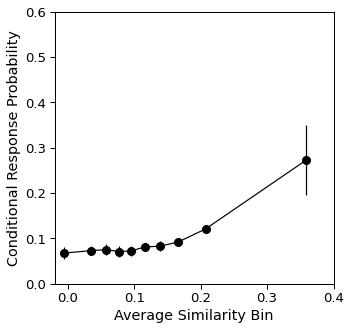

In [10]:
def std_ddof(a):
    std = np.std(a, ddof=1)
    return std

with sns.plotting_context(context='paper', font_scale=1.5): 
    fig = plt.figure(figsize=(5, 5))
    x = pb_sem_crp_sub.groupby('sem_bin').agg({'sem_bin_mean':'mean'})['sem_bin_mean'].to_numpy()
    y = pb_sem_crp_sub.groupby('sem_bin').agg({'prob':'mean'})['prob'].to_numpy()
    std = pb_sem_crp_sub.groupby('sem_bin').agg(std=('prob',std_ddof))['std'].to_numpy()
    count = pb_sem_crp_sub.groupby('sem_bin').agg(count=('prob','count'))['count'].to_numpy()
    yerr = 1.96 * (std / (count ** 0.5))

    plt.errorbar(x, y, yerr=yerr, color='k', marker='o', markersize=8);
    plt.ylim(0,0.60)
    plt.xlim(-0.02, 0.40)
    plt.xticks(np.arange(0,0.5, 0.1))
    plt.xlabel('Average Similarity Bin')
    plt.ylabel('Conditional Response Probability')
    plt.savefig('figures/exp2_semcrp.pdf')

## Change in the effect across sessions

In [10]:
exp2_dist_fact = sem_ffr_evs.groupby(['subject', 'session']).apply(
    pb.pd_dist_fact, itemno_column='item_num_new', list_index=['subject', 'session'], 
    pres_type="WORD", rec_type="REC_WORD", dist_mat=sem_sims, is_similarity=True).reset_index().rename(columns={0:'prob'})

In [11]:
exp2_dist_fact.to_csv('dataframes/exp2_sem.csv', index=False)

In [13]:
loftus_masson_sem=loftus_masson(exp2_dist_fact, 'subject', 'session', 'prob')

In [14]:
loftus_masson_sem.to_csv('dataframes/exp2_semtrend.csv', index=False)

# Lag-CRP

## Overall effect

In [12]:
lag_crp_ffr_evs = pd.concat([pres_evs, ffr_evs])

In [13]:
ffr_dfs=[]
for i in range(26):
    ffr_evs_crp=ffr_evs.copy()
    ffr_evs_crp['list']=i
    ffr_dfs.append(ffr_evs_crp)

In [14]:
ffr_dfs.append(pres_evs)
lag_crp_df = pd.concat(ffr_dfs)

In [22]:
pb_min_crp = lag_crp_df.groupby(['subject','session']).apply(pb.pd_min_crp, list_index=['subject', 'session', 'list'], lag_num=10,
                                itemno_column='item_num_new', max_n_reps=3).reset_index()

In [20]:
pb_min_crp_sub = pb_min_crp.groupby(['subject','lag']).agg({'prob':'mean'}).reset_index()

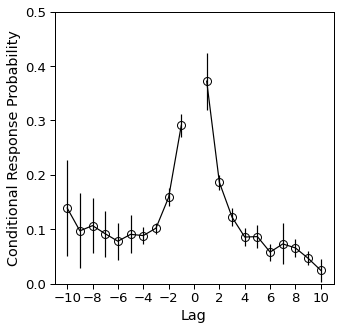

In [21]:
def std_ddof(a):
    std = np.std(a, ddof=1)
    return std

with sns.plotting_context(context='paper', font_scale=1.5): 
    fig = plt.figure(figsize=(5, 5))
    x = np.arange(-10,11,dtype=int)
    y = pb_min_crp_sub.groupby('lag').agg({'prob':'mean'})['prob'].to_numpy()
    std = pb_min_crp_sub.groupby('lag').agg(std=('prob',std_ddof))['std'].to_numpy()
    count = pb_min_crp_sub.groupby('lag').agg(count=('prob','count'))['count'].to_numpy()
    yerr = 1.96 * (std / (count ** 0.5))

    plt.errorbar(x, y, yerr=yerr, color='k', marker='o', markersize=8, fillstyle='none');
    plt.ylim(0,0.5)
    plt.xlabel('Lag')
    plt.ylabel('Conditional Response Probability')
    plt.xticks(np.arange(-10,11,2))
    #plt.savefig('figures/exp2_lag.pdf')

## Change in the effect across sessions 

In [15]:
exp2_temp_fact = lag_crp_df.groupby(['subject', 'session']).apply(
    pb.pd_min_temp_fact, pres_type="WORD", rec_type='REC_WORD',
    itemno_column='item_num_new', max_n_reps=3).to_frame('temp_fact').reset_index().rename(columns={'temp_fact':'prob'})

In [16]:
exp2_temp_fact.to_csv('dataframes/exp2_temp.csv', index=False)

In [23]:
loftus_masson_temp=loftus_masson(exp2_temp_fact, 'subject', 'session', 'prob')

## Combining sem and temp in same graph

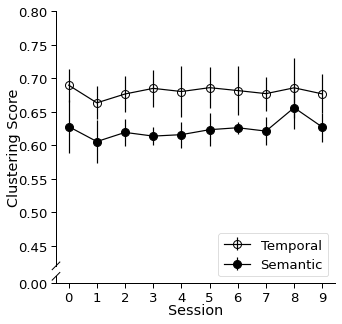

In [24]:
def std_ddof(a):
    std = np.std(a, ddof=1)
    return std

with sns.plotting_context(context='paper', font_scale=1.5, 
#                           rc={'axes.labelsize': 100}
                         ):
    fig = plt.figure(figsize=(5, 5))
    bax = brokenaxes(ylims=((0, 0.01), (0.42
                                        , 0.80)), hspace=.08)
    x = np.arange(0,10,dtype=int)
    
    y_temp = loftus_masson_temp.groupby('session').agg(sem_prob=('adj_prob','mean'))['sem_prob'].to_numpy()
    std_temp = loftus_masson_temp.groupby('session').agg(std=('adj_prob',std_ddof))['std'].to_numpy()
    count_temp = loftus_masson_temp.groupby('session').agg(count=('adj_prob', 'count'))['count'].to_numpy()
    yerr_temp = 1.96 * (std_temp / (count_temp ** 0.5))
    bax.errorbar(x, y_temp, yerr = yerr_temp, color='k', marker='o', markersize=8,fillstyle='none',label='Temporal')
    
    y_sem = loftus_masson_sem.groupby('session').agg(sem_prob=('adj_prob','mean'))['sem_prob'].to_numpy()
    std_sem = loftus_masson_sem.groupby('session').agg(std=('adj_prob',std_ddof))['std'].to_numpy()
    count_sem = loftus_masson_sem.groupby('session').agg(count=('adj_prob', 'count'))['count'].to_numpy()
    yerr_sem = 1.96 * (std_sem / (count_sem ** 0.5))
    bax.errorbar(x, y_sem, yerr = yerr_sem, color='k', marker='o',markersize=8, label='Semantic')
    
  
    
    

    bax.legend(loc=4)
    
    bax.set_xticks(np.arange(1,10,1,dtype=int))
    bax.set_xlabel('Session')
    bax.set_ylabel('Clustering Score')
    plt.savefig('figures/exp2_sem_and_temp.pdf')

# Subjective CRP

## Overall effect 

In [17]:
# give item numbers to recalled items that will serve as presetation items
item_col = 'item_name'
item_num_col = 'ffr_item_num'
item_num_df = ffr_evs.drop_duplicates(subset=item_col, ignore_index=True)[item_col].reset_index().rename(columns={'index': item_num_col})
item_num_df[item_num_col] = item_num_df[item_num_col] + 1
ffr_evs = ffr_evs.merge(item_num_df, how='left')

In [18]:
# make the this df into a presentation events df
ffr_pres_evs = ffr_evs.copy()
ffr_pres_evs['type'] = "FFR_WORD"  # creates a distinction between pres and rec evs
ffr_pres_evs['session'] = ffr_pres_evs['session'] + 1   # add 1 to sess bc. analysis based on prev sess
ffr_pres_evs = ffr_pres_evs.query('session!=10')

In [19]:
num_recs = ffr_pres_evs.groupby(['subject','session']).agg(num_recs=('item_name','count')).reset_index()

In [20]:
ffr_pres_evs = ffr_pres_evs.merge(num_recs, on=['subject','session'], how='left')

In [21]:
# only keep sessions with more than 10 recalls serving as presentation events
ffr_pres_evs = ffr_pres_evs[ffr_pres_evs['num_recs']>10]

In [22]:
# session 0 has no prev sess, so no presenation evs
ffr_rec_evs = ffr_evs.query('session != 0') 

In [23]:
ffr_subj_org_evs = pd.concat([ffr_pres_evs, ffr_rec_evs])

In [16]:
pb_min_subj = ffr_subj_org_evs.groupby(['subject', 'session']).apply(pb_min.pd_min_crp_subj, lag_num=10,
                                                   pres_type='FFR_WORD',
                                          rec_type='REC_WORD', 
                                          itemno_column='ffr_item_num', 
                                           max_n_reps=4).reset_index()

In [17]:
pb_min_subj_sub = pb_min_subj.groupby(['subject', 'lag']).agg({'prob':'mean'}).reset_index()

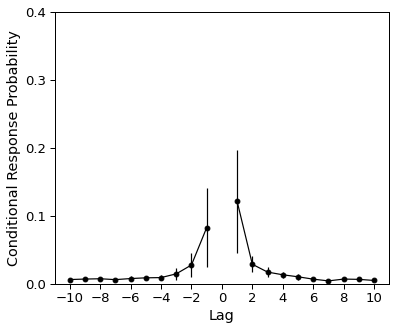

In [26]:
def std_ddof(a):
    std = np.std(a, ddof=1)
    return std

with sns.plotting_context(context='paper', font_scale=1.5): 
    fig = plt.figure(figsize=(6, 5))
    x = np.arange(-10,11,dtype=int)
    y = pb_min_subj_sub.groupby('lag').agg({'prob':'mean'})['prob'].to_numpy()
    std = pb_min_subj_sub.groupby('lag').agg(std=('prob',std_ddof))['std'].to_numpy()
    count = pb_min_subj_sub.groupby('lag').agg(count=('prob','count'))['count'].to_numpy()
    yerr = 1.96 * (std / (count ** 0.5))

    plt.errorbar(x, y, yerr=yerr, color='k', marker='o');
    plt.ylim(0,0.40)
    plt.yticks(np.arange(0,0.5,0.1))
    plt.xlabel('Lag')
    plt.ylabel('Conditional Response Probability')
    plt.xticks(np.arange(-10,11,2))
    plt.savefig('figures/exp2_subj.pdf')

## Change in the effect across sessions

In [24]:
exp2_subj_fact = ffr_subj_org_evs.groupby(['subject', 'session']).apply(
    pb.pd_min_temp_fact, pres_type="FFR_WORD", rec_type='REC_WORD', list_index=['subject', 'session'],
    itemno_column='ffr_item_num', max_n_reps=4).to_frame('prob').reset_index()

In [25]:
exp2_subj_fact = exp2_subj_fact.dropna(axis='rows')

In [26]:
exp2_subj_fact.to_csv('dataframes/exp2_subj.csv', index=False)

In [38]:
loftus_masson_subj=loftus_masson(exp2_subj_fact, 'subject', 'session', 'prob')

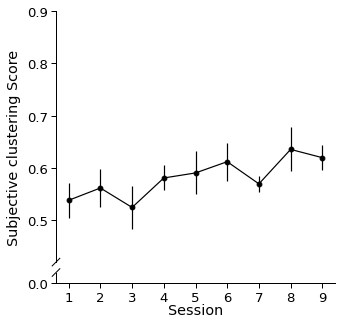

In [39]:
def std_ddof(a):
    std = np.std(a, ddof=1)
    return std

with sns.plotting_context(context='paper', font_scale=1.5, 
#                           rc={'axes.labelsize': 100}
                         ):
    fig = plt.figure(figsize=(5, 5))
    bax = brokenaxes(ylims=((0, 0.02), (0.42
                                        , 0.90)), hspace=.08)
    x = np.arange(1,10,dtype=int)
    y = loftus_masson_subj.groupby('session').agg(subj_prob=('adj_prob','mean'))['subj_prob'].to_numpy()
    std = loftus_masson_subj.groupby('session').agg(std=('adj_prob',std_ddof))['std'].to_numpy()
    count = loftus_masson_subj.groupby('session').agg(count=('adj_prob', 'count'))['count'].to_numpy()

    yerr = 1.96 * (std / (count ** 0.5))
    bax.errorbar(x, y, yerr = yerr, color='k', marker='o' )
    bax.set_xticks(np.arange(1,10,1,dtype=int))
    bax.set_xlabel('Session')
    bax.set_ylabel('Subjective clustering Score')
    plt.savefig('figures/exp2_subjtrend.pdf')

## Subjective CRP at session S based on S-1 and S-2

In [8]:
fr_data = exp2_data.query("type == 'REC_WORD'")
fr_data = fr_data[fr_data['list']==26]

In [9]:
subjects = fr_data.subject.unique()

In [10]:
# dictionary with the list of recalls per sess for each sub
for sub in subjects:
    sub_df = fr_data[fr_data['subject']==sub]
    recs_per_sess = []
    for sess, sess_df in sub_df.groupby('session'):
        sess_recs = sess_df.item_name.to_list()
        recs_per_sess.append(sess_recs)
    with open(f'recalls_data/{sub}_recs_per_sess.pkl', 'wb') as f:
        pickle.dump(recs_per_sess, f)

In [14]:
# create a dictionary for each subject where the sess num is paired
# with its list of recalls, and their serial positions.

for sub in subjects:
    recs_per_sess_dict = {}
    with open(f'recalls_data/{sub}_recs_per_sess.pkl', 'rb') as f:
        recs_per_sess_lst = pickle.load(f)
    
    sub_data = fr_data[fr_data['subject']==sub]
    sessions = sub_data.session.unique()
    
    for s, sess in enumerate(sessions):
        recs = np.array(recs_per_sess_lst[s], dtype=object)  # Use dtype=object if elements are strings

        # Create serial positions
        serialpos = np.arange(1, (len(recs) + 1), dtype=int)



        # Update dictionary
        recs_per_sess_dict[sess] = [recs, serialpos]
    
    with open(f'recalls_data/{sub}_recs_and_sp_per_sess_dict.pkl', 'wb') as f:
        pickle.dump(recs_per_sess_dict, f)

In [15]:
min(list(recs_per_sess_dict.keys()))

0

In [16]:
# the list of possible bins
from itertools import product

# Define the arrays (excluding 0)
lags = list(range(-4, 0)) + list(range(1, 5))  # [-4, -3, -2, -1, 1, 2, 3, 4]

    

In [17]:
def get_min_trans(serialpos, rec):
    # positive values come first so argmin will select positive values
    # See Howard and Kahana 2005 for method -- always select positive in case of tie
    pt = [sp - r for sp in serialpos for r in rec if len(serialpos)>0 and len(rec)>0]
    pt.sort(reverse=True)
    if len(pt)>0:
        return pt[np.argmin(np.abs(pt))]
    else:
        return np.nan

In [62]:
# Lag-CRP with categories of far and close in s-2

In [20]:
def lag_crp_2d_cat(sub, lags):

    # dict with all bins, to update as we loop over recalls
    actual_lag_dict_close = {l: 0 for l in lags}
    actual_lag_dict_far = {l: 0 for l in lags}  

    poss_lag_dict_close = {l: 0 for l in lags}
    poss_lag_dict_far = {l: 0 for l in lags}

    with open(f'recalls_data/{sub}_recs_and_sp_per_sess_dict.pkl', 'rb') as f:
        recs_sp_dict = pickle.load(f)
    
    sessions = list(recs_sp_dict.keys())
    sessions_gr1 = [s for s in sessions if s>1]

    for s in sessions_gr1:

        # reset counters here for a version of the code where you get prob values at the session-level

        sess_data = recs_sp_dict[s]
        recs = sess_data[0]

        if (s-1 in sessions) and (s-2 in sessions): # check that these sessions exist
            # get recalls and sps from sess s-1
            sess_1back_data = recs_sp_dict[s-1]
            recs_1back = sess_1back_data[0]
            sps_1back = sess_1back_data[1]

            # get recalls and sps from sess s-2
            sess_2back_data = recs_sp_dict[s-2]
            recs_2back = sess_2back_data[0]
            sps_2back = sess_2back_data[1]

            # get the list of serial positions of possible recalls at s-1 and s-2
            # possible recalls are common recalls in s-1 and s-2
            common_recs_1b_2b = np.intersect1d(recs_1back, recs_2back)

            poss_sp_dict = {}
            for c_rec in common_recs_1b_2b:
                sp_1back = sps_1back[np.where(recs_1back==c_rec)[0]]
                # sp_2back = sps_2back[np.where(recs_2back==c_rec)[0]]
                poss_sp_dict.update({c_rec:sp_1back})
                
            # sets to keep track of the sps of already recalled words
            seen = set()
            # seen_1back = set()
            # seen_2back = set()

            for r in range(len(recs) - 1):
                this_rec, next_rec = recs[r], recs[r + 1]
                seen.add(this_rec)
                
                
                if {this_rec, next_rec}.issubset(set(recs_1back)) and {this_rec, next_rec}.issubset(set(recs_2back)):
                    # Get serial positions in s-1 and s-2 for this recall pair
                    sp_this_rec_1back = sps_1back[np.where(recs_1back == this_rec)[0]]
                    sp_next_rec_1back = sps_1back[np.where(recs_1back == next_rec)[0]]
                    sp_this_rec_2back = sps_2back[np.where(recs_2back == this_rec)[0]]
                    sp_next_rec_2back = sps_2back[np.where(recs_2back == next_rec)[0]]

                    # Determine lag bins
                    actual_1back = get_min_trans(sp_next_rec_1back, sp_this_rec_1back)
                    actual_2back = get_min_trans(sp_next_rec_2back, sp_this_rec_2back)

                    incremented_lags = set()
                    
                    if abs(actual_2back) <= 2:
                        if actual_1back in lags:
                            actual_lag_dict_close[actual_1back] += 1
                        
                        for poss in common_recs_1b_2b:
                            if poss in seen:
                                continue  # Skip if already seen

                            poss_1back = get_min_trans(poss_sp_dict[poss], sp_this_rec_1back)

                            if poss_1back in lags and poss_1back not in incremented_lags:
                                poss_lag_dict_close[poss_1back] += 1
                                incremented_lags.add(poss_1back)
                    
                    if abs(actual_2back) > 2:
                        if actual_1back in lags:
                            actual_lag_dict_far[actual_1back] += 1
                            
                            
                        for poss in common_recs_1b_2b:
                            if poss in seen:
                                continue  # Skip if already seen

                            poss_1back = get_min_trans(poss_sp_dict[poss], sp_this_rec_1back)

                            if poss_1back in lags and poss_1back not in incremented_lags:
                                poss_lag_dict_far[poss_1back] += 1
                                incremented_lags.add(poss_1back)




    crps_close = [actual_lag_dict_close[b] / poss_lag_dict_close[b] if poss_lag_dict_close[b] != 0 else np.nan for b in lags]
    crps_far = [actual_lag_dict_far[b] / poss_lag_dict_far[b] if poss_lag_dict_far[b] != 0 else np.nan for b in lags]
    crp_dict_close = {l: (crp if l != 0 else np.nan) for l, crp in zip(lags, crps_close)}     
    crp_dict_far = {l: (crp if l != 0 else np.nan) for l, crp in zip(lags, crps_far)}

    return crp_dict_close, crp_dict_far

In [21]:
lags = list(range(-10, 1)) + list(range(0, 11))
crp_dicts_close = []
crp_dicts_far = []

for sub in subjects:
    crp_dict_close, crp_dict_far = lag_crp_2d_cat(sub, lags)
    crp_dicts_close.append(crp_dict_close)
    crp_dicts_far.append(crp_dict_far)

In [22]:
mean_crp_dict_close = {key: np.nanmean([d[key] for d in crp_dicts_close]) for key in crp_dicts_close[0]}
mean_crp_dict_far = {key: np.nanmean([d[key] for d in crp_dicts_far]) for key in crp_dicts_far[0]}

/home1/rafla/.conda/envs/cml_environment/lib/python3.7/site-packages/ipykernel_launcher.py:1: RuntimeWarning: Mean of empty slice
  """Entry point for launching an IPython kernel.
/home1/rafla/.conda/envs/cml_environment/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: Mean of empty slice
  


In [23]:
std_crp_dict_close = {key: np.nanstd([d[key] for d in crp_dicts_close]) for key in crp_dicts_close[0]}
std_crp_dict_far = {key: np.nanstd([d[key] for d in crp_dicts_far]) for key in crp_dicts_far[0]}

/home1/rafla/.conda/envs/cml_environment/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1665: RuntimeWarning: Degrees of freedom <= 0 for slice.
  keepdims=keepdims)


In [24]:
count_dict_close = {
    key: sum(1 for d in crp_dicts_close if not np.isnan(d[key]))
    for key in crp_dicts_close[0]
}
count_dict_far = {
    key: sum(1 for d in crp_dicts_far if not np.isnan(d[key]))
    for key in crp_dicts_close[0]
}

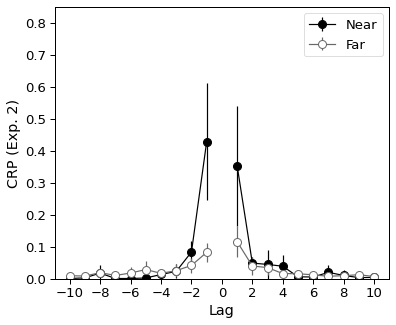

In [26]:
with sns.plotting_context(context='paper', font_scale=1.5, 
#                           rc={'axes.labelsize': 100}
                         ):
    fig = plt.figure(figsize=(6, 5))
    #bax = brokenaxes(ylims=((0, 0.01), (0.42
                                        #, 0.80)), hspace=.08)
    x = list(mean_crp_dict_close.keys()) 
    y_close = list(mean_crp_dict_close.values())
    std_close = np.array(list(std_crp_dict_close.values()))
    count_close = np.array(list(count_dict_close.values()))
    yerr_close = 1.96 * (std_close / (count_close ** 0.5))
    plt.errorbar(x, y_close, yerr = yerr_close, color='k', marker='o', markersize=8, label='Near')
    
    y_far = list(mean_crp_dict_far.values())
    std_far = np.array(list(std_crp_dict_far.values()))
    count_far = np.array(list(count_dict_far.values()))
    yerr_far = 1.96 * (std_far / (count_far ** 0.5))
    plt.errorbar(x, y_far, yerr = yerr_far, color='dimgray', marker='o', markerfacecolor='white', markersize=8,  label='Far')
    
    plt.ylim(0,0.85)
    plt.xticks(np.arange(-10,11,2))
    plt.xlabel('Lag')
    plt.ylabel('CRP (Exp. 2)')
    plt.legend()
    plt.savefig('figures/exp2_2d_subjcrp.pdf')

## Subjective organization measured by Pair Frequency

In [4]:
# Get exp2 equivalent
fr_data = exp2_data.query("type == 'REC_WORD'")
fr_data = fr_data[fr_data['list']==26]

In [5]:
subjects = fr_data.subject.unique()

In [6]:
# dictionary with the list of recalls per sess for each sub
for sub in subjects:
    sub_df = fr_data[fr_data['subject']==sub]
    recs_per_sess = []
    for sess, sess_df in sub_df.groupby('session'):
        sess_recs = sess_df.item_name.to_list()
        recs_per_sess.append(sess_recs)
    with open(f'recalls_data/{sub}_recs_per_sess.pkl', 'wb') as f:
        pickle.dump(recs_per_sess, f)


In [7]:
# For each subject and session, O, c, h and k

Observed_PF_per_sub = []
common_items_sub = []
num_recs_i_i1_sub = []

for sub in subjects:
    # load the dictionary with the list of words recalled per session
    with open(f'recalls_data/{sub}_recs_per_sess.pkl', 'rb') as f:
        recs_per_sess = pickle.load(f)
    
    num_recs_i_i1_per_sess = []
    Observed_PF_per_sess = [] 
    common_items_per_sess = []
    
    for sess in range(len(recs_per_sess)-1):
        
        # get recalls of current session
        sess_recs = recs_per_sess[sess]
        
        # get set of recalled items in current session
        sess_recs_set = set(sess_recs)
        # get number of recalls on session i
        num_recs_i = len(sess_recs_set)
        
        # create a dictionary with all pairs recalled in sess i, with counter set to 0
        pairs_dict = {}
        for i in range(len(sess_recs)-1):
            pair = (sess_recs[i], sess_recs[i+1])
            pairs_dict.update({pair:0})
            
        # Get recalls of next session
        next_sess_recs = recs_per_sess[sess+1]
        
        # Get recalls of next session
        next_sess_recs_set = set(next_sess_recs)
        # get number of recalls in session i+1
        num_recs_i1 = len(next_sess_recs_set)
        num_recs_i_i1_per_sess.append([num_recs_i, num_recs_i1])
        
        # count common items recalled in sess i and i+1
        common_words = sess_recs_set & next_sess_recs_set  # Finds common elements
        num_common_words = len(common_words)
        common_items_per_sess.append(num_common_words)
        
        # increment the pairs that were recalled on both sessions (regardless of order)
        for j in range(len(next_sess_recs)-1):
            next_sess_pair = (next_sess_recs[j], next_sess_recs[j+1])
            for key in list(pairs_dict.keys()):
                if set(next_sess_pair) == set(key):
                    pairs_dict[key] +=1
                    
        Observed_PF = sum(pairs_dict.values())
        Observed_PF_per_sess.append(Observed_PF)
    
    num_recs_i_i1_sub.append(num_recs_i_i1_per_sess)
    common_items_sub.append(common_items_per_sess)
    Observed_PF_per_sub.append(Observed_PF_per_sess)

In [8]:
# For each subject, session, get PF

PF_per_sub = []

for s in range(len(subjects)):
    num_recs = num_recs_i_i1_sub[s]
    c = common_items_sub[s]
    O = Observed_PF_per_sub[s]
    
    PF_per_sess = []
    
    for i in range(len(num_recs)):
        PF_i = O[i] - ((2 * c[i] * (c[i]-1))/(num_recs[i][0] * num_recs[i][1]))
        PF_per_sess.append(PF_i)
        
    PF_per_sub.append(PF_per_sess)
        
                 


In [9]:
# Create a DF with subject, sess, PF
dfs = []
sub_sess_df = fr_data[['subject', 'session']].drop_duplicates(subset=['subject', 'session'])
#sub_sess_df = sub_sess_df[sub_sess_df['session']!=]

for i, (sub, df) in enumerate(sub_sess_df.groupby('subject')):
    sessions = df.session.unique()
    df = df[df['session'] != min(sessions)]
    df["prob"] = PF_per_sub[i]
    dfs.append(df)

/home1/rafla/.conda/envs/cml_environment/lib/python3.7/site-packages/ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if __name__ == '__main__':


In [10]:
df_combined = pd.concat(dfs, ignore_index=True)

In [34]:
df_combined.to_csv('dataframes/exp2_subj_PF.csv', index=False)

In [11]:
def loftus_masson(df, sub_cols, cond_col, value_col, within_cols=[]):
    if not isinstance(sub_cols, list):
        sub_cols = [sub_cols]
    if not isinstance(within_cols, list):
        within_cols = [within_cols]
    df = df.copy()
    if len(within_cols) > 0:
        df['M'] = df.groupby(within_cols)[value_col].transform('mean')
    else:
        df['M'] = df[value_col].mean()
    df['M_S'] = df.groupby(sub_cols + within_cols)[value_col].transform('mean')
    df['adj_' + value_col] = (df[value_col] + df['M'] - df['M_S'])
    return df

In [12]:
loftus_masson_subj=loftus_masson(df_combined, 'subject', 'session', 'prob')

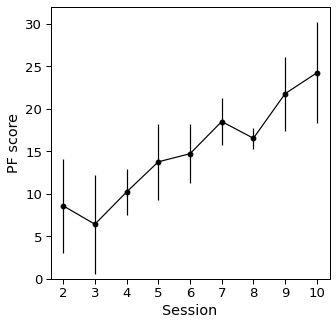

In [13]:
def std_ddof(a):
    std = np.std(a, ddof=1)
    return std

with sns.plotting_context(context='paper', font_scale=1.5, 
#                           rc={'axes.labelsize': 100}
                         ):
    fig = plt.figure(figsize=(5, 5))
    #bax = brokenaxes(ylims=((0, 0.02), (0.42
                                        #, 0.90)), hspace=.08)
    x = np.arange(2,11,dtype=int)
    y = loftus_masson_subj.groupby('session').agg(subj_prob=('adj_prob','mean'))['subj_prob'].to_numpy()
    std = loftus_masson_subj.groupby('session').agg(std=('adj_prob',std_ddof))['std'].to_numpy()
    count = loftus_masson_subj.groupby('session').agg(count=('adj_prob', 'count'))['count'].to_numpy()

    yerr = 1.96 * (std / (count ** 0.5))
    plt.errorbar(x, y, yerr=yerr, color='k', marker='o');
    plt.ylim(0,32)
    plt.xlabel('Session')
    plt.ylabel('PF score')
    plt.xticks(np.arange(2,11))

    plt.savefig('figures/exp2_PF_trend.pdf')